In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [2]:
base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
print(os.listdir(base_path))

['val', '.DS_Store', 'test', 'train']


In [3]:
path_train = os.path.join(base_path, 'train')
pneumonia_content = os.path.join(path_train, 'PNEUMONIA')
normal_lung = os.path.join(path_train, 'NORMAL')

print(os.listdir(path_train))

['PNEUMONIA', 'NORMAL', '.DS_Store']


## **label sparsing**

In [4]:
import pandas as pd 
records = []

for filename in os.listdir(pneumonia_content):
    if filename.startswith("."):  # ignore .DS_Store ET ._xxx.jpeg
        continue
    parts = filename.split("_")
    patient_id = parts[0]
    label = parts[1]
    records.append({"filename": filename, "patient_id": patient_id, "label": label})

for filename_normal in os.listdir(normal_lung):
    if filename_normal.startswith("."):
        continue
    records.append({
        "filename": filename_normal,
        "patient_id": filename_normal,
        "label": "normal"
    })

df = pd.DataFrame(records)
print(df.shape)
print(df["label"].value_counts())
    
    

(5216, 3)
label
bacteria    2530
virus       1345
normal      1341
Name: count, dtype: int64


In [5]:
df["filepath"] = df.apply(
    lambda row: os.path.join(normal_lung, row["filename"]) if row["label"] == "normal"
    else os.path.join(pneumonia_content, row["filename"]),
    axis=1
)
print("df columns:", df.columns)

df columns: Index(['filename', 'patient_id', 'label', 'filepath'], dtype='object')


## **Split patient-safe**

In [6]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df["label"], groups=df["patient_id"]))
train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

print(train_df.shape, test_df.shape)

(4179, 4) (1037, 4)


In [7]:
from sklearn.model_selection import StratifiedGroupKFold

skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(skf.split(train_df, train_df["label"], groups=train_df["patient_id"]))

train_idx_fold0, val_idx_fold0 = splits[0]
fold0_train = train_df.iloc[train_idx_fold0]
fold0_val = train_df.iloc[val_idx_fold0]

print(fold0_train.shape, fold0_val.shape)

(3313, 4) (866, 4)


## **balance dataset**

In [8]:
def balance_dataset(df_in, n_per_class=200, random_state=42):
    balanced_dfs = []
    for label in df_in["label"].unique():
        class_subset = df_in[df_in["label"] == label]
        sampled = class_subset.sample(n=n_per_class, random_state=random_state)
        balanced_dfs.append(sampled)
    return pd.concat(balanced_dfs)
 
fold0_train_balanced = balance_dataset(fold0_train, n_per_class=200)
print("fold0_train_balanced columns:", fold0_train_balanced.columns)
print("fold0_train_balanced label counts:\n", fold0_train_balanced["label"].value_counts())

fold0_train_balanced columns: Index(['filename', 'patient_id', 'label', 'filepath'], dtype='object')
fold0_train_balanced label counts:
 label
virus       200
bacteria    200
normal      200
Name: count, dtype: int64


## **Preprocessing (grayscale, 128x128)**

In [9]:
!pip install monai
from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, Resize,
    ScaleIntensity, RandRotate, Lambda
)
 
def force_single_channel(img):
    if img.shape[0] > 1:
        img = img.mean(dim=0, keepdim=True)
    return img
 
to_grayscale = Lambda(force_single_channel)
 
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    to_grayscale,
    Resize((128, 128)),
    ScaleIntensity(),
    RandRotate(range_x=0.05, prob=0.3),
])
 
val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    to_grayscale,
    Resize((128, 128)),
    ScaleIntensity(),
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.6 MB/s eta 0:00:00


## **Dataset class**

In [10]:
from torch.utils.data import Dataset, DataLoader
class XrayDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df = dataframe
        self.transforms = transforms
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = self.transforms(row["filepath"])
        label_map = {"bacteria": 0, "virus": 1, "normal": 2}
        label = label_map[row["label"]]
        return image, label

In [11]:
train_dataset = XrayDataset(fold0_train_balanced, train_transforms)
val_dataset = XrayDataset(fold0_val, val_transforms)
 
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
 
images, labels = next(iter(train_loader))
print("Batch check:", images.shape, labels.shape)  # expect [16, 1, 128, 128], [16]

Batch check: torch.Size([16, 1, 128, 128]) torch.Size([16])


## **Modèle VGG**

In [12]:
from torchvision.models import vgg16, VGG16_Weights
import torch
import torch.nn as nn
import torch.optim as optim

model = vgg16(weights=VGG16_Weights.DEFAULT)
 
# Replace first conv layer: 3 channels -> 1 channel
model.features[0] = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=(3, 3),
    stride=(1, 1),
    padding=(1, 1)
)
 
# Replace last classifier layer: 1000 -> 3 classes
model.classifier[6] = nn.Linear(in_features=4096, out_features=3)
 
# Freeze everything, then unfreeze only the two replaced layers
for param in model.parameters():
    param.requires_grad = False
for param in model.features[0].parameters():
    param.requires_grad = True
for param in model.classifier[6].parameters():
    param.requires_grad = True
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
model = model.to(device)
 
criterion = nn.CrossEntropyLoss()  # no class weights needed, data already balanced 200/200/200
 
optimizer = optim.Adam(
    list(model.features[0].parameters()) + list(model.classifier[6].parameters()),
    lr=0.001
)
 
print("Pipeline ready. Model, data, optimizer all set for training.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 182MB/s]


Device: cuda
Pipeline ready. Model, data, optimizer all set for training.


## **Entraînement**

In [13]:
best_val_acc = 0.0
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = correct / total

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_accuracy:.4f}")

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model_vgg_fold0.pth")
        print(f"  -> Nouveau meilleur modèle sauvegardé (Val Acc: {val_accuracy:.4f})")

Epoch 1/30 - Train Loss: 1.1000 - Val Loss: 1.0106 - Val Acc: 0.4203
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.4203)
Epoch 2/30 - Train Loss: 0.9278 - Val Loss: 0.9060 - Val Acc: 0.5300
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.5300)
Epoch 3/30 - Train Loss: 0.8771 - Val Loss: 0.9539 - Val Acc: 0.4053
Epoch 4/30 - Train Loss: 0.8710 - Val Loss: 0.9123 - Val Acc: 0.4307
Epoch 5/30 - Train Loss: 0.7899 - Val Loss: 0.9871 - Val Acc: 0.4226
Epoch 6/30 - Train Loss: 0.7741 - Val Loss: 0.8353 - Val Acc: 0.5162
Epoch 7/30 - Train Loss: 0.7489 - Val Loss: 0.7310 - Val Acc: 0.6744
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.6744)
Epoch 8/30 - Train Loss: 0.7418 - Val Loss: 0.8180 - Val Acc: 0.5855
Epoch 9/30 - Train Loss: 0.7303 - Val Loss: 0.7523 - Val Acc: 0.6293
Epoch 10/30 - Train Loss: 0.6718 - Val Loss: 0.7986 - Val Acc: 0.5196
Epoch 11/30 - Train Loss: 0.7129 - Val Loss: 0.7182 - Val Acc: 0.6836
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.6836)
Epoch 1

In [14]:
import numpy as np

# Vérification de sécurité : aucun fichier caché ne doit être dans df
hidden_files = df[df["filename"].str.startswith(".")]
print("Fichiers cachés détectés:", len(hidden_files))
if len(hidden_files) > 0:
    print(hidden_files)

def train_and_evaluate_fold(fold_idx, train_idx, val_idx, train_df, num_epochs=30):
    print(f"FOLD {fold_idx}")

    # Split train/val pour ce fold
    fold_train = train_df.iloc[train_idx]
    fold_val = train_df.iloc[val_idx]

    # Équilibrage 200/200/200 sur le train de ce fold
    fold_train_balanced = balance_dataset(fold_train, n_per_class=200)

    # Dataset + DataLoader
    train_dataset = XrayDataset(fold_train_balanced, train_transforms)
    val_dataset = XrayDataset(fold_val, val_transforms)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # Nouveau modèle VGG à chaque fold (recommencer à zéro, pas réutiliser l'ancien)
    model = vgg16(weights=VGG16_Weights.DEFAULT)
    model.features[0] = nn.Conv2d(1, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1))
    model.classifier[6] = nn.Linear(in_features=4096, out_features=3)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[0].parameters():
        param.requires_grad = True
    for param in model.classifier[6].parameters():
        param.requires_grad = True

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        list(model.features[0].parameters()) + list(model.classifier[6].parameters()),
        lr=0.001
    )

    best_val_acc = 0.0
    best_model_path = f"best_model_vgg_fold{fold_idx}.pth"

    for epoch in range(num_epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        val_accuracy = correct / total

        print(f"  Epoch {epoch+1}/{num_epochs} - Val Acc: {val_accuracy:.4f}")

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), best_model_path)

    print(f"Fold {fold_idx} - Best Val Acc: {best_val_acc:.4f}")
    return best_model_path, best_val_acc


# ---- Boucle sur les 5 folds ----
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(splits):
    model_path, val_acc = train_and_evaluate_fold(fold_idx, train_idx, val_idx, train_df, num_epochs=30)
    fold_results.append({"fold": fold_idx, "val_acc": val_acc, "model_path": model_path})

print("\n--- Résumé des 5 folds ---")
for r in fold_results:
    print(f"Fold {r['fold']}: Val Acc = {r['val_acc']:.4f}")

mean_acc = np.mean([r["val_acc"] for r in fold_results])
std_acc = np.std([r["val_acc"] for r in fold_results])
print(f"\nMoyenne: {mean_acc:.4f} (+/- {std_acc:.4f})")

Fichiers cachés détectés: 0
FOLD 0
  Epoch 1/30 - Val Acc: 0.4169
  Epoch 2/30 - Val Acc: 0.4480
  Epoch 3/30 - Val Acc: 0.6570
  Epoch 4/30 - Val Acc: 0.6582
  Epoch 5/30 - Val Acc: 0.6871
  Epoch 6/30 - Val Acc: 0.6801
  Epoch 7/30 - Val Acc: 0.6836
  Epoch 8/30 - Val Acc: 0.6478
  Epoch 9/30 - Val Acc: 0.6478
  Epoch 10/30 - Val Acc: 0.6940
  Epoch 11/30 - Val Acc: 0.7044
  Epoch 12/30 - Val Acc: 0.5727
  Epoch 13/30 - Val Acc: 0.6513
  Epoch 14/30 - Val Acc: 0.4861
  Epoch 15/30 - Val Acc: 0.5577
  Epoch 16/30 - Val Acc: 0.7055
  Epoch 17/30 - Val Acc: 0.5704
  Epoch 18/30 - Val Acc: 0.7136
  Epoch 19/30 - Val Acc: 0.7044
  Epoch 20/30 - Val Acc: 0.5878
  Epoch 21/30 - Val Acc: 0.6386
  Epoch 22/30 - Val Acc: 0.6363
  Epoch 23/30 - Val Acc: 0.6905
  Epoch 24/30 - Val Acc: 0.6963
  Epoch 25/30 - Val Acc: 0.6120
  Epoch 26/30 - Val Acc: 0.6859
  Epoch 27/30 - Val Acc: 0.6778
  Epoch 28/30 - Val Acc: 0.6594
  Epoch 29/30 - Val Acc: 0.6594
  Epoch 30/30 - Val Acc: 0.7090
Fold 0 - Best 

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Recharge le modèle du meilleur fold
model = vgg16(weights=VGG16_Weights.DEFAULT)
model.features[0] = nn.Conv2d(1, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1))
model.classifier[6] = nn.Linear(in_features=4096, out_features=3)
model.load_state_dict(torch.load("best_model_vgg_fold3.pth"))
model = model.to(device)
model.eval()

test_dataset = XrayDataset(test_df, val_transforms)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

class_names = ["bacteria", "virus", "normal"]
print(classification_report(test_labels, test_preds, target_names=class_names))
print(confusion_matrix(test_labels, test_preds))

              precision    recall  f1-score   support

    bacteria       0.82      0.69      0.75       515
       virus       0.52      0.59      0.55       237
      normal       0.79      0.92      0.85       285

    accuracy                           0.73      1037
   macro avg       0.71      0.74      0.72      1037
weighted avg       0.74      0.73      0.73      1037

[[356 115  44]
 [ 70 141  26]
 [  7  16 262]]


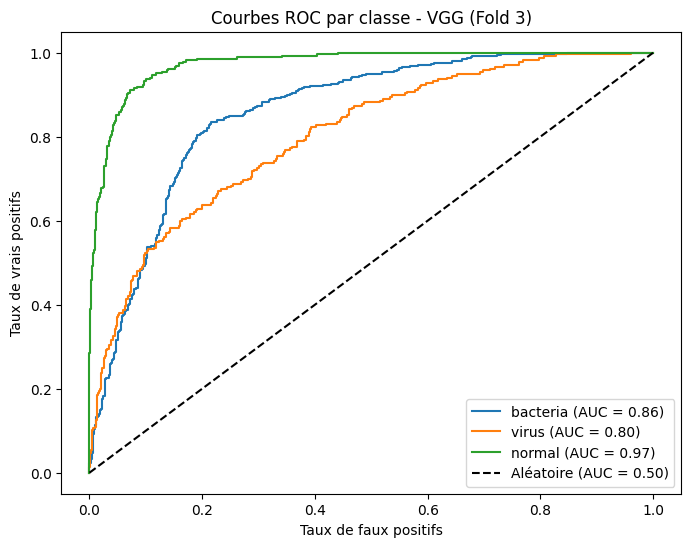

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Recharge le modèle du meilleur fold (si pas déjà fait)
model = vgg16(weights=VGG16_Weights.DEFAULT)
model.features[0] = nn.Conv2d(1, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1))
model.classifier[6] = nn.Linear(in_features=4096, out_features=3)
model.load_state_dict(torch.load("best_model_vgg_fold3.pth"))
model = model.to(device)
model.eval()

test_dataset = XrayDataset(test_df, val_transforms)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # scores bruts -> probabilités (somme = 1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Binarise les labels : pour chaque classe, 1 si c'est cette classe, 0 sinon
class_names = ["bacteria", "virus", "normal"]
labels_binarized = label_binarize(all_labels, classes=[0, 1, 2])

# Calcule la courbe ROC pour chaque classe
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_binarized[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire (AUC = 0.50)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC par classe - VGG (Fold 3)")
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import precision_recall_curve

# Probabilité prédite pour la classe virus (colonne 1) uniquement
virus_probs = all_probs[:, 1]
virus_true = (all_labels == 1).astype(int)

precisions, recalls, thresholds = precision_recall_curve(virus_true, virus_probs)

# Cherche le seuil qui donne le meilleur F1 pour virus
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Meilleur seuil pour virus: {best_threshold:.3f}")
print(f"Precision à ce seuil: {precisions[best_idx]:.3f}")
print(f"Recall à ce seuil: {recalls[best_idx]:.3f}")
print(f"F1 à ce seuil: {f1_scores[best_idx]:.3f}")
print(f"\nF1 actuel (seuil 0.5 implicite): 0.44")

Meilleur seuil pour virus: 0.513
Precision à ce seuil: 0.603
Recall à ce seuil: 0.532
F1 à ce seuil: 0.565

F1 actuel (seuil 0.5 implicite): 0.44


In [18]:
# Recrée les données du fold 3 (le meilleur fold)
train_idx_f3, val_idx_f3 = splits[3]
fold3_train = train_df.iloc[train_idx_f3]
fold3_val = train_df.iloc[val_idx_f3]
fold3_train_balanced = balance_dataset(fold3_train, n_per_class=200)

train_dataset = XrayDataset(fold3_train_balanced, train_transforms)
val_dataset = XrayDataset(fold3_val, val_transforms)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Nouveau modèle avec dégel supplémentaire (features[0] + dernier bloc conv + classifier[6])
model = vgg16(weights=VGG16_Weights.DEFAULT)
model.features[0] = nn.Conv2d(1, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1))
model.classifier[6] = nn.Linear(in_features=4096, out_features=3)

for param in model.parameters():
    param.requires_grad = False
for param in model.features[0].parameters():
    param.requires_grad = True
for param in model.features[24:30].parameters():
    param.requires_grad = True
for param in model.classifier[6].parameters():
    param.requires_grad = True

model = model.to(device)

optimizer = optim.Adam(
    list(model.features[0].parameters()) +
    list(model.features[24:30].parameters()) +
    list(model.classifier[6].parameters()),
    lr=0.0001
)

criterion = nn.CrossEntropyLoss()

# Vérification
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

features.0.weight
features.0.bias
features.24.weight
features.24.bias
features.26.weight
features.26.bias
features.28.weight
features.28.bias
classifier.6.weight
classifier.6.bias


In [19]:
best_val_acc = 0.0
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    correct, total = 0, 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = correct / total

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_accuracy:.4f}")

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model_vgg_finetuned.pth")
        print(f"  -> Nouveau meilleur modèle sauvegardé (Val Acc: {val_accuracy:.4f})")

Epoch 1/30 - Train Loss: 1.0591 - Val Loss: 0.9606 - Val Acc: 0.5434
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.5434)
Epoch 2/30 - Train Loss: 0.8038 - Val Loss: 0.7524 - Val Acc: 0.7060
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.7060)
Epoch 3/30 - Train Loss: 0.7142 - Val Loss: 0.6440 - Val Acc: 0.7444
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.7444)
Epoch 4/30 - Train Loss: 0.6636 - Val Loss: 0.6627 - Val Acc: 0.7072
Epoch 5/30 - Train Loss: 0.5816 - Val Loss: 0.6144 - Val Acc: 0.7357
Epoch 6/30 - Train Loss: 0.5356 - Val Loss: 0.6487 - Val Acc: 0.7519
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.7519)
Epoch 7/30 - Train Loss: 0.5197 - Val Loss: 0.5723 - Val Acc: 0.7742
  -> Nouveau meilleur modèle sauvegardé (Val Acc: 0.7742)
Epoch 8/30 - Train Loss: 0.4746 - Val Loss: 0.7111 - Val Acc: 0.7196
Epoch 9/30 - Train Loss: 0.4467 - Val Loss: 0.6566 - Val Acc: 0.6600
Epoch 10/30 - Train Loss: 0.4675 - Val Loss: 0.5164 - Val Acc: 0.7928
  -> Nouveau meille

In [20]:
model.load_state_dict(torch.load("best_model_vgg_finetuned.pth"))
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

class_names = ["bacteria", "virus", "normal"]
print(classification_report(test_labels, test_preds, target_names=class_names))
print(confusion_matrix(test_labels, test_preds))


              precision    recall  f1-score   support

    bacteria       0.82      0.82      0.82       515
       virus       0.60      0.59      0.59       237
      normal       0.91      0.92      0.92       285

    accuracy                           0.80      1037
   macro avg       0.78      0.78      0.78      1037
weighted avg       0.80      0.80      0.80      1037

[[424  76  15]
 [ 87 139  11]
 [  5  17 263]]


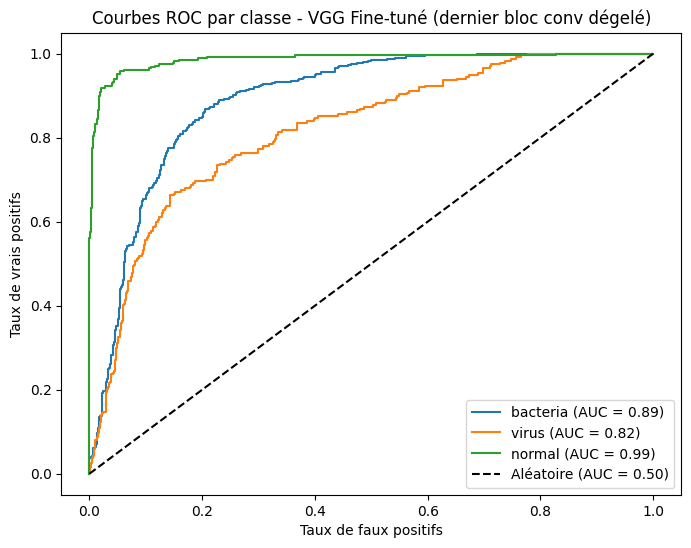

In [21]:
model.load_state_dict(torch.load("best_model_vgg_finetuned.pth"))
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

labels_binarized = label_binarize(all_labels, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_binarized[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire (AUC = 0.50)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC par classe - VGG Fine-tuné (dernier bloc conv dégelé)")
plt.legend()
plt.show()